# 06 - Overfitting und UGM-Leakage sichtbar machen

Dieses Notebook erzeugt absichtlich einen problematischen Split:

1. Einige komplette UGM-IDs werden zuerst als **unbekannter UGM-Test**
   weggeschlossen.
2. Die übrigen Zeilen werden **ohne Gruppierung zufällig** in Train,
   Validation und einen naiven Test aufgeteilt.

Im naiven Test tauchen deshalb häufig dieselben UGM-IDs wie im Training
auf. Ein flexibles Modell kann ihre spezifischen Muster wiedererkennen.
Der unbekannte UGM-Test zeigt anschließend, wie gut das wirklich auf neue
Gasmischungen generalisiert. Ethanol ist als Standard gewählt, weil der
Abstand zwischen beiden Tests hier besonders deutlich ist.

## Software, Versuchsaufbau und veränderbare Parameter

Dieses Notebook ist absichtlich eine Negativdemonstration und darf nicht als
gültige Baseline verwendet werden.

**Eingaben**

- GAS wählt das Ziel; Ethanol zeigt den Unterschied besonders deutlich.
- N_ALA_SEGMENTS steuert die Anzahl der ALA-Segmente.
- HELD_OUT_UGM_FRACTION legt den Anteil vollständig unbekannter UGM-IDs fest.
- RANDOM_STATE_DEMO macht Gruppenwahl, Zeilensplit und Bäume reproduzierbar.

sklearn.model_selection.GroupShuffleSplit hält zuerst komplette UGMs zurück.
train_test_split zerlegt danach den Rest absichtlich zeilenweise und erzeugt
UGM-Leakage. sklearn.ensemble.ExtraTreesRegressor kombiniert viele stark
randomisierte Entscheidungsbäume.

Wichtige Extra-Trees-Parameter:

- n_estimators: Zahl der Bäume; mehr reduziert Zufallsschwankungen, kostet Zeit.
- min_samples_leaf: Mindestzahl je Blatt; 1 erlaubt nahezu vollständiges
  Memorieren, größere Werte glätten.
- max_features: Anteil der Merkmale pro Teilung.
- n_jobs = -1 nutzt alle verfügbaren CPU-Kerne.

Die Scatterplots vergleichen Wiedererkennen bekannter UGMs mit echter
Generalisierung. Hohe Trainingsgüte allein ist kein Qualitätsnachweis.

In [1]:
# Ethanol zeigt den Leakage-/Generalisierungsunterschied besonders klar.
GAS = "ethanol"
N_ALA_SEGMENTS = 50
HELD_OUT_UGM_FRACTION = 0.20
RANDOM_STATE_DEMO = 17

In [2]:
from pathlib import Path
from html import escape
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GroupShuffleSplit, train_test_split

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from physics_features import extract_ala_features, learn_ala_breakpoints

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unbekanntes Gas: {GAS}")
plt.style.use("seaborn-v0_8-whitegrid")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>" for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Einen naiven und einen ehrlichen Test konstruieren

In [3]:
original = prepare_splits("stored")
X_all = np.concatenate([original[name]["X"] for name in SPLIT_NAMES])
y_all = np.concatenate([
    original[name]["targets"][GAS] for name in SPLIT_NAMES
]).astype(float)
ugm_all = np.concatenate([
    original[name]["targets"]["range"] for name in SPLIT_NAMES
]).astype(int)

# Für die Demonstration bleibt die Konzentrationsregion UGM 1-500 gleich.
base = ugm_all <= BASE_SEGMENT_MAX_UGM
X_all, y_all, ugm_all = X_all[base], y_all[base], ugm_all[base]
all_positions = np.arange(len(X_all))

group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=HELD_OUT_UGM_FRACTION,
    random_state=RANDOM_STATE_DEMO,
)
development_pos, unseen_ugm_pos = next(
    group_splitter.split(X_all, y_all, groups=ugm_all)
)

# Absichtlich zeilenweise: gleiche UGM-IDs dürfen in mehreren Splits stehen.
train_val_pos, random_test_pos = train_test_split(
    development_pos, test_size=0.20, random_state=RANDOM_STATE_DEMO
)
train_pos, val_pos = train_test_split(
    train_val_pos, test_size=0.20, random_state=RANDOM_STATE_DEMO
)
positions = {
    "train": train_pos,
    "val": val_pos,
    "random_test": random_test_pos,
    "unseen_ugm_test": unseen_ugm_pos,
}

train_ugms = set(ugm_all[train_pos])
split_rows = []
for name, index in positions.items():
    groups = set(ugm_all[index])
    overlap = len(groups & train_ugms)
    split_rows.append({
        "Split": name,
        "Zeilen": len(index),
        "UGM-IDs": len(groups),
        "UGM-Überlappung mit Train": overlap,
        "Zeilen mit Train-UGM [%]":
            100 * np.mean(np.isin(ugm_all[index], list(train_ugms))),
    })
show_table(split_rows, list(split_rows[0]), digits=1)

Split,Zeilen,UGM-IDs,UGM-Überlappung mit Train,Zeilen mit Train-UGM [%]
train,869,380,380,100.0
val,218,191,177,90.4
random_test,272,213,195,87.5
unseen_ugm_test,343,100,0,0.0


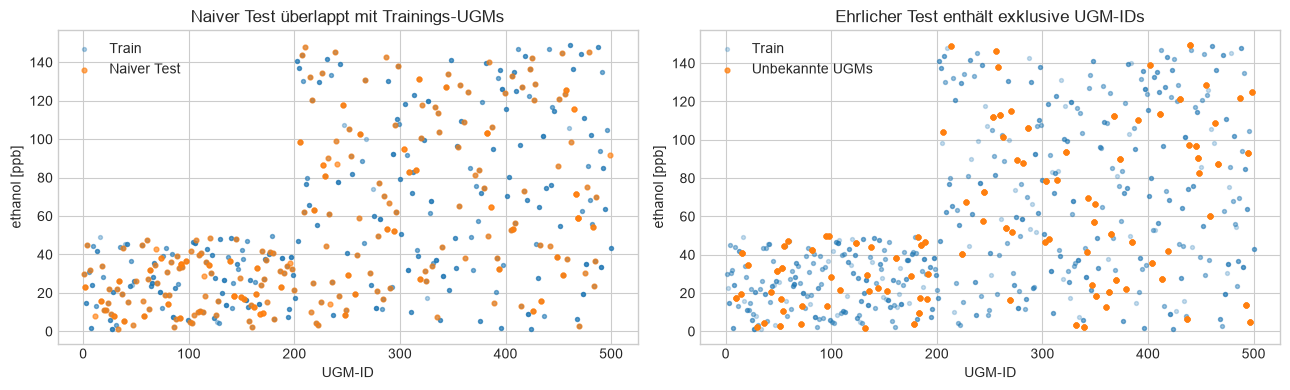

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(ugm_all[train_pos], y_all[train_pos], s=8, alpha=0.35,
                label="Train")
axes[0].scatter(ugm_all[random_test_pos], y_all[random_test_pos],
                s=12, alpha=0.65, label="Naiver Test")
axes[0].set(xlabel="UGM-ID", ylabel=f"{GAS} [ppb]",
            title="Naiver Test überlappt mit Trainings-UGMs")
axes[0].legend()

axes[1].scatter(ugm_all[train_pos], y_all[train_pos], s=8, alpha=0.25,
                label="Train")
axes[1].scatter(ugm_all[unseen_ugm_pos], y_all[unseen_ugm_pos],
                s=12, alpha=0.75, label="Unbekannte UGMs")
axes[1].set(xlabel="UGM-ID", ylabel=f"{GAS} [ppb]",
            title="Ehrlicher Test enthält exklusive UGM-IDs")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Gleiches Merkmal, gleiches Modell – nur der Test ist anders

Verwendet werden wieder 50 ALA-Segmente mit Mittelwert und Steigung.
Segmentgrenzen werden ausschließlich auf dem Trainingsmedian gelernt.
Extra Trees ist absichtlich flexibel gewählt, damit der Unterschied
zwischen Wiedererkennen und Generalisieren deutlich wird.

In [5]:
train_reference = np.median(X_all[train_pos, 0, :], axis=0)
breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=N_ALA_SEGMENTS
)
X_features, feature_names = extract_ala_features(X_all, breakpoints)
print("ALA-Merkmale:", X_features.shape[1])
print("Segmentgrenzen nur aus Train gelernt:", len(breakpoints))

def regression_metrics(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)
    mse = float(np.mean(residual ** 2))
    denominator = float(np.sum((y_true - np.mean(y_true)) ** 2))
    return {
        "R2": 1 - float(np.sum(residual ** 2)) / denominator,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": float(np.mean(np.abs(residual))),
    }

model = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=RANDOM_STATE_DEMO,
    n_jobs=-1,
)
model.fit(X_features[train_pos], y_all[train_pos])

predictions = {
    name: model.predict(X_features[index])
    for name, index in positions.items()
}
metric_rows = []
for name, index in positions.items():
    metric_rows.append({
        "Split": name,
        **regression_metrics(y_all[index], predictions[name]),
    })
show_table(metric_rows, ["Split", "R2", "MSE", "RMSE", "MAE"])

ALA-Merkmale: 100
Segmentgrenzen nur aus Train gelernt: 51


Split,R2,MSE,RMSE,MAE
train,1.000,0.000,0.000,0.000
val,0.688,559.378,23.651,17.291
random_test,0.694,510.273,22.589,17.123
unseen_ugm_test,0.228,1289.020,35.903,28.918


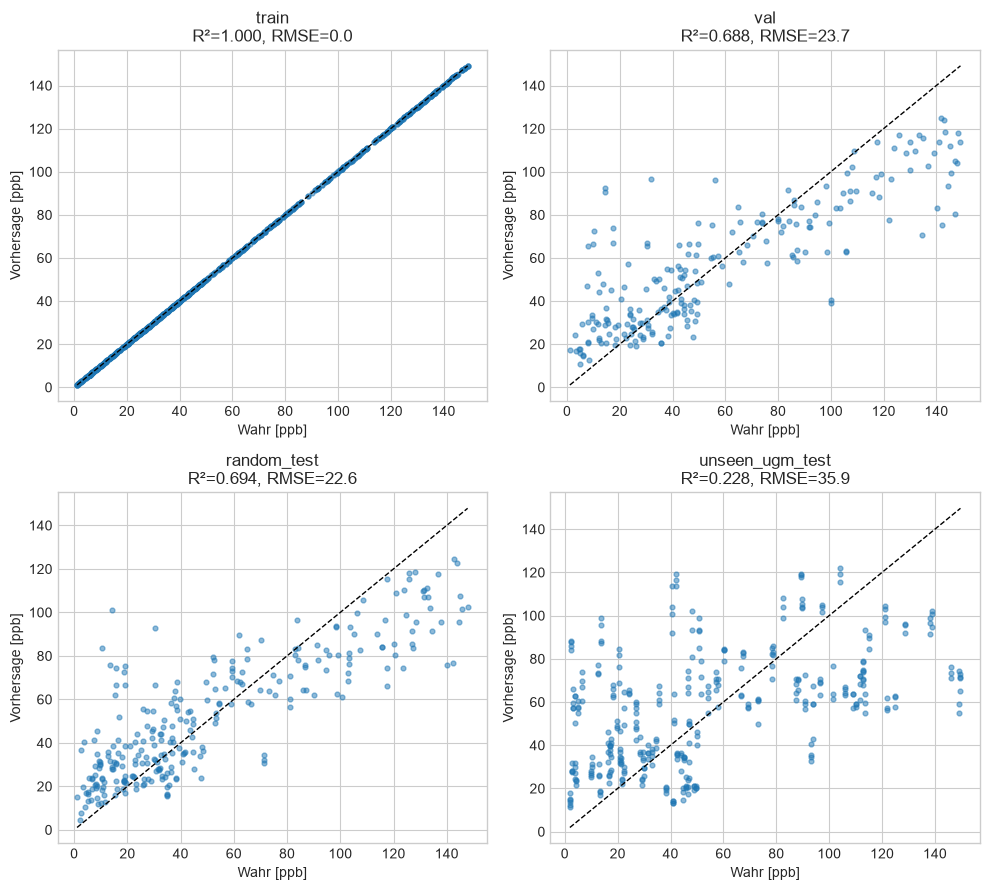

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, (name, index) in zip(axes.flat, positions.items()):
    truth = y_all[index]
    prediction = predictions[name]
    lower = min(float(truth.min()), float(prediction.min()))
    upper = max(float(truth.max()), float(prediction.max()))
    score = regression_metrics(truth, prediction)
    ax.scatter(truth, prediction, s=12, alpha=0.5)
    ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
    ax.set(
        xlabel="Wahr [ppb]", ylabel="Vorhersage [ppb]",
        title=f"{name}\nR²={score['R2']:.3f}, RMSE={score['RMSE']:.1f}",
    )
plt.tight_layout()
plt.show()

## 3. Overfitting über eine klar geordnete Modellkomplexität

Komplexitätsstufe,min_samples_leaf,Interpretation,R2 train,R2 random_test,R2 unseen_ugm_test
1,32,einfach / stark geglättet,0.471,0.404,0.284
2,16,einfach / stark geglättet,0.618,0.477,0.268
3,8,mittel,0.797,0.568,0.252
4,4,mittel,0.946,0.643,0.227
5,2,flexibel / viele kleine Blätter,0.996,0.671,0.222
6,1,flexibel / viele kleine Blätter,1.000,0.691,0.224


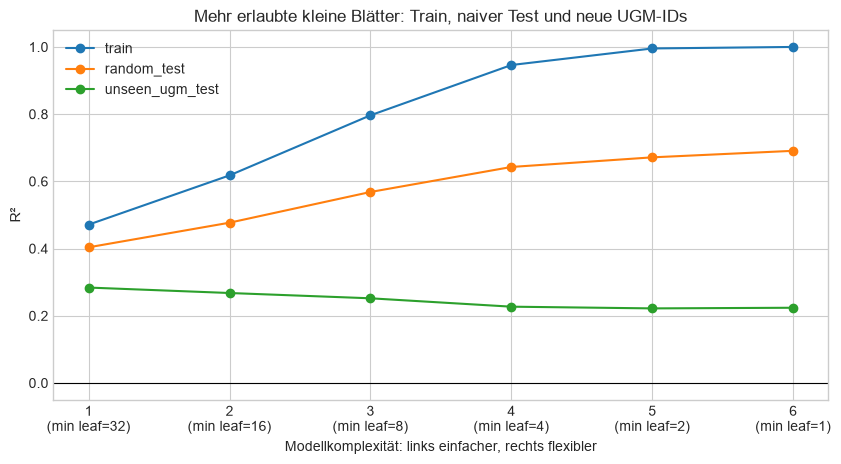

In [7]:
# min_samples_leaf ist NICHT die Anzahl der Blätter.
# Große Werte erzwingen große, wenige Blätter und ein einfaches Modell.
# Kleine Werte erlauben viele kleine Blätter und ein flexibles Modell.
leaf_sizes = [32, 16, 8, 4, 2, 1]
complexity_rows = []
for complexity_step, leaf_size in enumerate(leaf_sizes, start=1):
    candidate = ExtraTreesRegressor(
        n_estimators=200,
        min_samples_leaf=leaf_size,
        max_features=1.0,
        random_state=RANDOM_STATE_DEMO,
        n_jobs=-1,
    )
    candidate.fit(X_features[train_pos], y_all[train_pos])
    row = {
        "Komplexitätsstufe": complexity_step,
        "min_samples_leaf": leaf_size,
        "Interpretation": (
            "einfach / stark geglättet" if leaf_size >= 16
            else "mittel" if leaf_size >= 4
            else "flexibel / viele kleine Blätter"
        ),
    }
    for name in ("train", "random_test", "unseen_ugm_test"):
        index = positions[name]
        prediction = candidate.predict(X_features[index])
        row[f"R2 {name}"] = regression_metrics(y_all[index], prediction)["R2"]
    complexity_rows.append(row)

show_table(complexity_rows, list(complexity_rows[0]))

fig, ax = plt.subplots(figsize=(10, 4.8))
complexity_steps = [row["Komplexitätsstufe"] for row in complexity_rows]
for split in ("train", "random_test", "unseen_ugm_test"):
    ax.plot(
        complexity_steps,
        [row[f"R2 {split}"] for row in complexity_rows],
        marker="o",
        label=split,
    )
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(complexity_steps)
ax.set_xticklabels([
    f"{step}\n(min leaf={leaf_size})"
    for step, leaf_size in zip(complexity_steps, leaf_sizes)
])
ax.set(
    xlabel="Modellkomplexität: links einfacher, rechts flexibler",
    ylabel="R²",
    title="Mehr erlaubte kleine Blätter: Train, naiver Test und neue UGM-IDs",
)
ax.legend()
plt.show()

## Was hier als Overfitting zählt

Wichtig: `min_samples_leaf` ist **nicht** die Anzahl der Blätter.
Ein Wert von 32 verlangt mindestens 32 Trainingszeilen in jedem Blatt.
Dadurch entstehen wenige große Blätter und ein stark geglättetes,
einfaches Modell. Ein Wert von 1 erlaubt dagegen viele kleine Blätter
und damit ein sehr flexibles Modell. Die Grafik ordnet diese Werte
deshalb von links (einfach) nach rechts (komplex).

Mit wachsender Flexibilität sollte die Trainingsgüte steigen oder
zumindest nicht systematisch fallen. Sinkt gleichzeitig die Güte auf
unbekannten UGM-IDs nach einem Optimum, ist das der klassische
Generalisierungsgap: Das Modell passt sich Besonderheiten der
Trainings-UGMs an. Wird dagegen ein stärker geglättetes Modell überall
schlechter, ist das **Underfitting**, nicht Overfitting.

Ein sehr gutes Ergebnis im zufälligen Test ist in diesem Aufbau kein
Beweis für Generalisierung: Train und Test enthalten Messungen derselben
UGM-Situationen und damit dieselben Zielkonzentrationen und
Mischungsbedingungen. Das Modell kann UGM-spezifische Signaturen
wiedererkennen.

Erst der Split unseen_ugm_test beantwortet die praktisch relevante
Frage: Funktioniert das Modell auch für vollständig neue
Gasmischungen? Für seriöse Modellvergleiche bleiben deshalb die
gruppierten Splits aus Notebook 01–05 maßgeblich. Dieses Notebook ist
ausdrücklich eine Negativdemonstration.